# LAB WORK

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [92]:
df = pd.read_csv("C:\\Users\\Kishan Pawar\\Downloads\\btcusd_1-min_data.csv",encoding='latin1')
df

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
1,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
2,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
3,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
4,1.325412e+09,4.58,4.58,4.58,4.58,0.000000
...,...,...,...,...,...,...
7208311,1.757980e+09,115362.00,115388.00,115362.00,115385.00,1.482863
7208312,1.757980e+09,115385.00,115386.00,115385.00,115386.00,0.000302
7208313,1.757980e+09,115386.00,115433.00,115386.00,115433.00,0.146785
7208314,1.757980e+09,115433.00,115454.00,115432.00,115454.00,0.104604


In [ ]:
daily_df = df['Close'].resample('D').last()
daily_df = daily_df.dropna()
daily_df = daily_df[daily_df.index >= daily_df.index.max() - pd.DateOffset(years=2)]

train = daily_df.iloc[:-30]
test = daily_df.iloc[-30:]

In [97]:
model_111 = ARIMA(train, order=(1,1,1))
model_111_fit = model_111.fit()

model_212 = ARIMA(train, order=(2,1,2))
model_212_fit = model_212.fit()

d:\Visual Studio Code\Practice\Python3\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Visual Studio Code\Practice\Python3\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [96]:
pred_111 = model_111_fit.forecast(steps=len(test))
pred_212 = model_212_fit.forecast(steps=len(test))

In [94]:

def mean_scaled_error(actual, predicted):
    naive_forecast = actual.shift(1)
    naive_error = np.mean(np.abs(actual[1:] - naive_forecast[1:]))
    scaled_error = np.mean(np.abs(actual - predicted)) / naive_error
    return scaled_error

mse_111 = mean_scaled_error(test, pred_111)
mse_212 = mean_scaled_error(test, pred_212)

In [95]:
df = pd.read_csv("C:\\Users\\Kishan Pawar\\Downloads\\btcusd_1-min_data.csv",encoding='latin1')

df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.sort_values(by='Timestamp')
df.set_index('Timestamp', inplace=True)


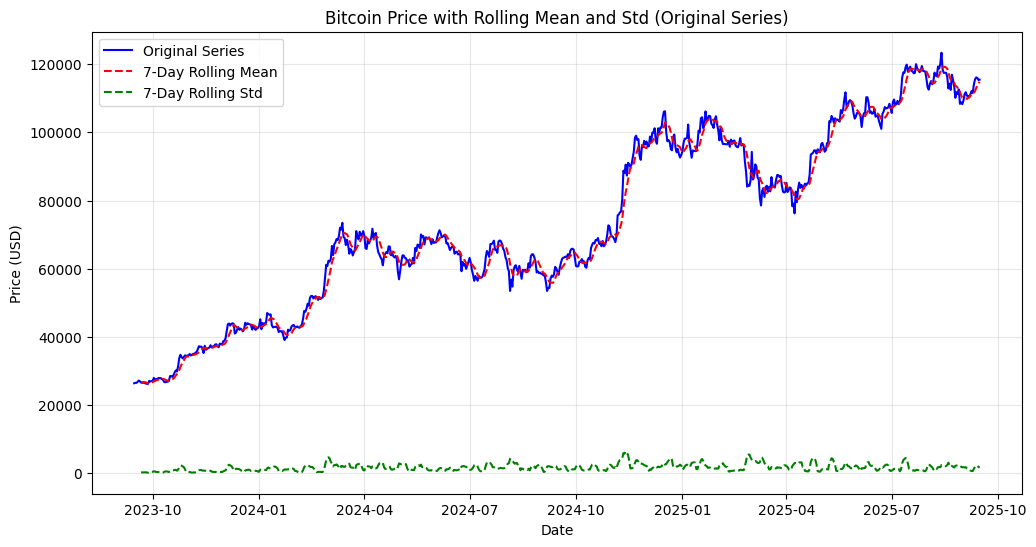

In [98]:
daily_df = df['Close'].resample('D').last().dropna()
daily_df = daily_df[daily_df.index >= daily_df.index.max() - pd.DateOffset(years=2)]

rolling_window = 7
rolling_mean = daily_df.rolling(window=rolling_window).mean()
rolling_std = daily_df.rolling(window=rolling_window).std()

plt.figure(figsize=(12,6))
plt.plot(daily_df, label="Original Series", color='blue')
plt.plot(rolling_mean, label=f"{rolling_window}-Day Rolling Mean", color='red', linestyle='--')
plt.plot(rolling_std, label=f"{rolling_window}-Day Rolling Std", color='green', linestyle='--')
plt.title("Bitcoin Price with Rolling Mean and Std (Original Series)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Final differencing order: d=1, p-value=0.00000


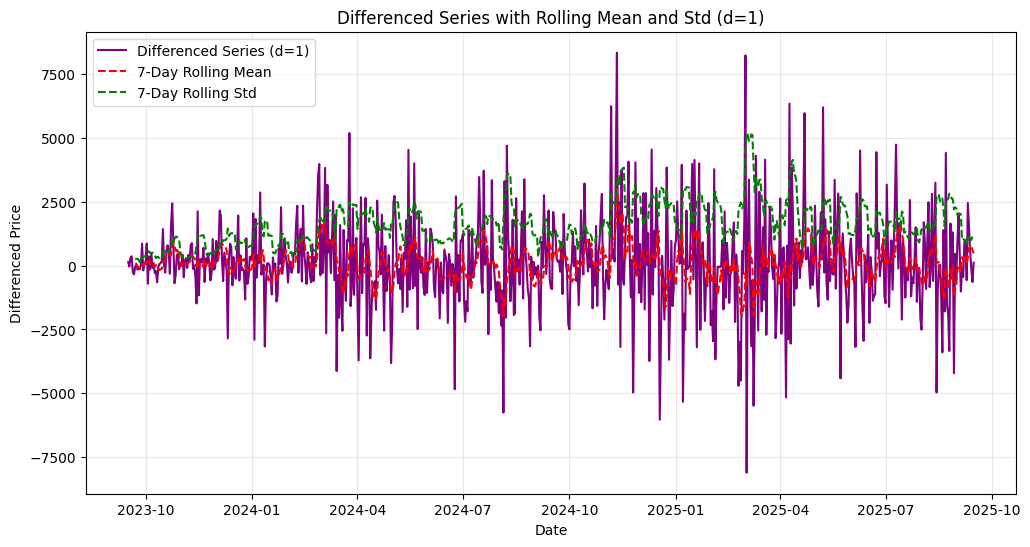

In [100]:

def adf_test(ts):
    return adfuller(ts.dropna())[1]

p_value = adf_test(daily_df)
differenced_series = daily_df.copy()
d = 0

while p_value > 0.05:
    differenced_series = differenced_series.diff().dropna()
    d += 1
    p_value = adf_test(differenced_series)

print(f"Final differencing order: d={d}, p-value={p_value:.5f}")

rolling_mean_diff = differenced_series.rolling(window=rolling_window).mean()
rolling_std_diff = differenced_series.rolling(window=rolling_window).std()

plt.figure(figsize=(12,6))
plt.plot(differenced_series, label=f"Differenced Series (d={d})", color='purple')
plt.plot(rolling_mean_diff, label=f"{rolling_window}-Day Rolling Mean", color='red', linestyle='--')
plt.plot(rolling_std_diff, label=f"{rolling_window}-Day Rolling Std", color='green', linestyle='--')
plt.title(f"Differenced Series with Rolling Mean and Std (d={d})")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

d:\Visual Studio Code\Practice\Python3\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Visual Studio Code\Practice\Python3\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Mean Scaled Error ARIMA(1,1,1): 3.3939
Mean Scaled Error ARIMA(2,1,2): 3.3999


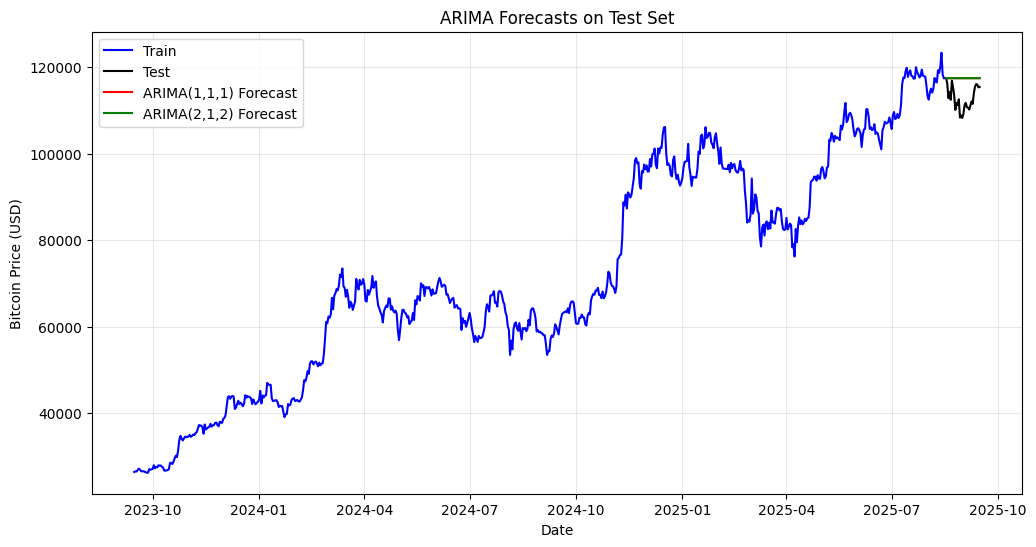

In [101]:
train_original = daily_df.iloc[:-30]
test_original = daily_df.iloc[-30:]

model_111 = ARIMA(train_original, order=(1,d,1))
model_111_fit = model_111.fit()

model_212 = ARIMA(train_original, order=(2,d,2))
model_212_fit = model_212.fit()

pred_111 = pd.Series(model_111_fit.forecast(steps=len(test_original)), index=test_original.index)
pred_212 = pd.Series(model_212_fit.forecast(steps=len(test_original)), index=test_original.index)

def mean_scaled_error(actual, predicted):
    naive_forecast = actual.shift(1)
    naive_error = np.mean(np.abs(actual[1:] - naive_forecast[1:]))
    return np.mean(np.abs(actual - predicted)) / naive_error

mse_111 = mean_scaled_error(test_original, pred_111)
mse_212 = mean_scaled_error(test_original, pred_212)
print(f"Mean Scaled Error ARIMA(1,{d},1): {mse_111:.4f}")
print(f"Mean Scaled Error ARIMA(2,{d},2): {mse_212:.4f}")

plt.figure(figsize=(12,6))
plt.plot(train_original, label="Train", color='blue')
plt.plot(test_original, label="Test", color='black')
plt.plot(pred_111, label=f"ARIMA(1,{d},1) Forecast", color='red')
plt.plot(pred_212, label=f"ARIMA(2,{d},2) Forecast", color='green')
plt.title("ARIMA Forecasts on Test Set")
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

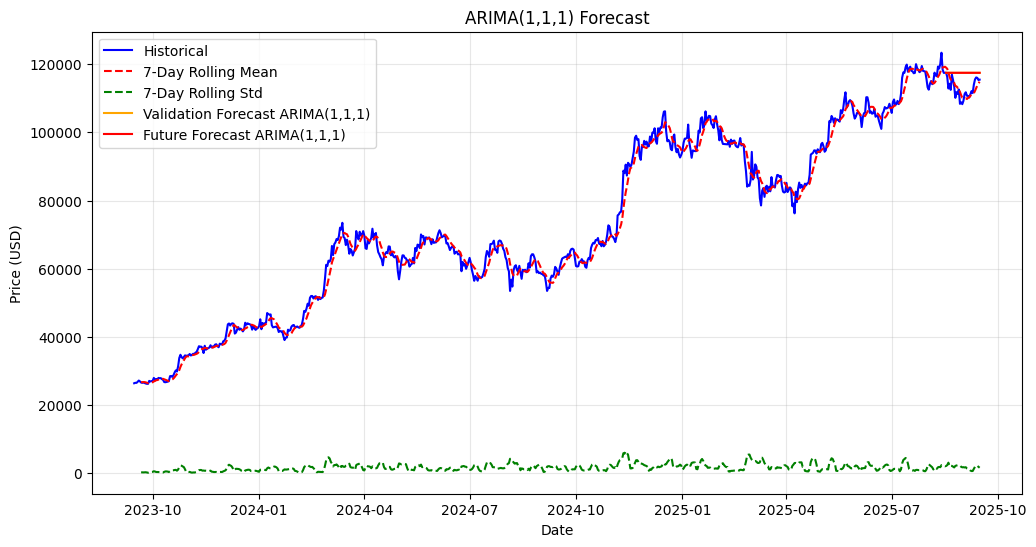

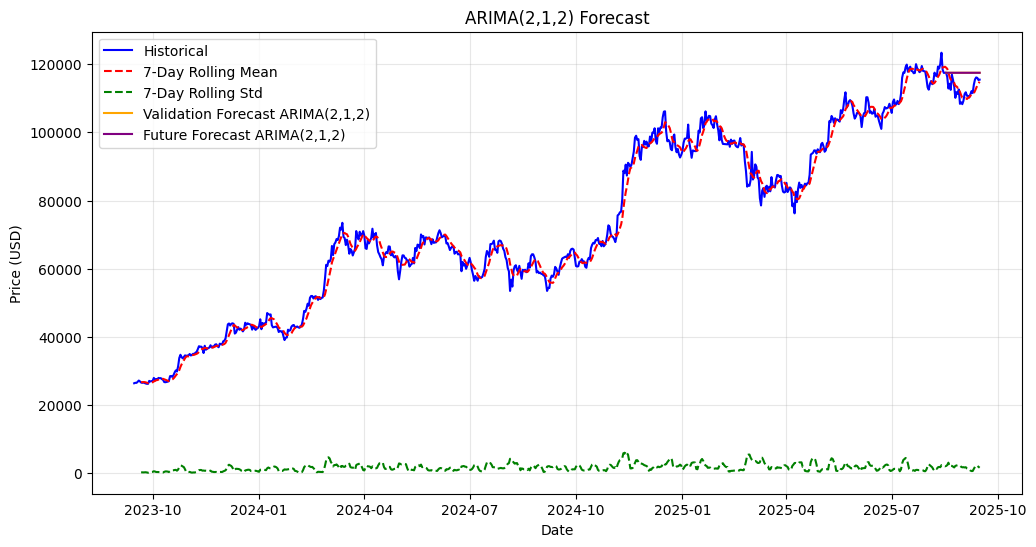

In [102]:
future_steps = 30
future_index = pd.date_range(train_original.index[-1] + pd.Timedelta(days=1),
                             periods=future_steps, freq='D')

forecast_111_series = pd.Series(model_111_fit.forecast(steps=future_steps), index=future_index)
forecast_212_series = pd.Series(model_212_fit.forecast(steps=future_steps), index=future_index)

plt.figure(figsize=(12,6))
plt.plot(daily_df, label="Historical", color='blue')
plt.plot(rolling_mean, label=f"{rolling_window}-Day Rolling Mean", color='red', linestyle='--')
plt.plot(rolling_std, label=f"{rolling_window}-Day Rolling Std", color='green', linestyle='--')
plt.plot(pred_111, label=f"Validation Forecast ARIMA(1,{d},1)", color='orange')
plt.plot(forecast_111_series, label=f"Future Forecast ARIMA(1,{d},1)", color='red')
plt.title(f"ARIMA(1,{d},1) Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(daily_df, label="Historical", color='blue')
plt.plot(rolling_mean, label=f"{rolling_window}-Day Rolling Mean", color='red', linestyle='--')
plt.plot(rolling_std, label=f"{rolling_window}-Day Rolling Std", color='green', linestyle='--')
plt.plot(pred_212, label=f"Validation Forecast ARIMA(2,{d},2)", color='orange')
plt.plot(forecast_212_series, label=f"Future Forecast ARIMA(2,{d},2)", color='purple')
plt.title(f"ARIMA(2,{d},2) Forecast")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()